In [84]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision import datasets, models
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from tqdm import tqdm
from PIL import Image

In [85]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [86]:
class TrashDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.file_list = os.listdir(root_dir)
        
        # Create a mapping for labels to numbers
        # e.g., {'cardboard': 0, 'plastic': 1}
        self.label_map = {"cardboard": 0, "plastic": 1, "glass": 2, "metal": 3, "paper": 4, "trash": 5}

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_name = self.file_list[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load image
        image = Image.open(img_path).convert("RGB")
        
        # Extract label from filename: train_cardboard_000.jpg -> cardboard
        label_str = img_name.split('_')[1]
        label = self.label_map[label_str]

        if self.transform:
            image = self.transform(image)

        return image, label

# Define your augmentation pipeline
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),      # Resize slightly larger first
    
    # --- DATA AUGMENTATION STARTS HERE ---
    transforms.RandomResizedCrop(224),  # Randomly zoom and crop to 224x224
    transforms.RandomHorizontalFlip(),  # 50% chance to flip the image
    transforms.RandomRotation(15),      # Rotate by +/- 15 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Slight color shifts
    # --- DATA AUGMENTATION ENDS HERE ---
    
    transforms.ToTensor(),              # Convert to PyTorch Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),     # Resize directly to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Load the base dataset (pass None for transform initially)
full_dataset = TrashDataset(root_dir='data/train', transform=None)

# Calculate lengths
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
remain_size = total_size - train_size
val_size = remain_size // 2
test_size = remain_size - val_size

# Perform the random split
train_indices, val_indices, test_indices = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) # For reproducible results
)

# A small helper class to apply transforms to the subsets
class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# Create the final datasets
train_data = ApplyTransform(train_indices, transform=train_transform)
val_data = ApplyTransform(val_indices, transform=test_transform)
test_data = ApplyTransform(test_indices, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")


Train: 2789 | Val: 598 | Test: 598


Image tensor shape: torch.Size([3, 224, 224])
Label index: 2 (Name: glass)


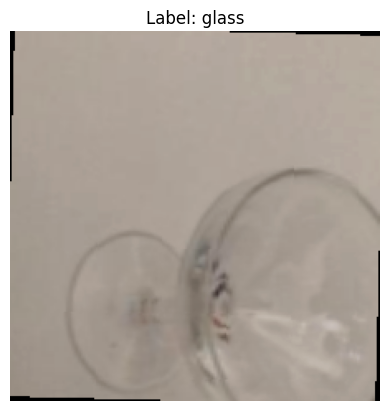

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Access the first item
image_tensor, label_idx = train_data[0]

# 2. Access the map through the subset layers
original_ds = train_data.subset.dataset
inv_label_map = {v: k for k, v in original_ds.label_map.items()}
label_name = inv_label_map[label_idx]

# 3. Print stats
print(f"Image tensor shape: {image_tensor.shape}") 
print(f"Label index: {label_idx} (Name: {label_name})")

# 4. Display
img_to_show = image_tensor.permute(1, 2, 0).numpy()
# Un-normalize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_to_show = std * img_to_show + mean
img_to_show = np.clip(img_to_show, 0, 1)

plt.imshow(img_to_show)
plt.title(f"Label: {label_name}")
plt.axis('off')
plt.show()

In [ ]:
from IPython.display import clear_output
import time
import copy
import torch
import numpy as np
from tqdm import tqdm

def train_model_dynamic(model, train_loader, val_loader, criterion, optimizer, num_epochs=25, patience=5):
    since = time.time()

    # Track history
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    log_messages = [] # We will store text logs here

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    best_acc = 0.0
    epochs_no_improve = 0
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

    for epoch in range(num_epochs):
        
        # --- DYNAMIC DISPLAY SECTION ---
        clear_output(wait=True) # Clear the previous output
        
        # Print the Dashboard
        print(f"=== Training Dashboard ===")
        print(f"Epoch: {epoch+1}/{num_epochs}")
        print(f"Best Val Acc: {best_acc:.4f}")
        print(f"Patience Used: {epochs_no_improve}/{patience}")
        print(f"Time Elapsed: {(time.time() - since):.0f}s")
        print("-" * 30)
        
        # Print the last 5 lines of history so you can see the trend
        print("Recent History:")
        for msg in log_messages[-5:]:
            print(msg)
        print("-" * 30)
        # -------------------------------

        # Each epoch has a training and validation phase
        epoch_results = [] # To store temp strings for this epoch
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Progress bar
            iter_bar = tqdm(dataloader, desc=phase, leave=False)
            
            for inputs, labels in iter_bar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # Update progress bar with current loss
                iter_bar.set_postfix(loss=loss.item())

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            # Save result string
            result_msg = f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}'
            epoch_results.append(result_msg)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                scheduler.step(epoch_loss)

                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'best_model.pth')
                    epoch_results.append(" [Saved Best Model!]")
                else:
                    epochs_no_improve += 1
        
        # Add this epoch's results to the log
        log_messages.append(f"Ep {epoch+1}: " + " | ".join(epoch_results))

        # Early Stopping check
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs!')
            break

    # Final Summary
    clear_output(wait=True)
    print("=== Training Complete ===")
    print(f"Total Time: {(time.time() - since) // 60:.0f}m {(time.time() - since) % 60:.0f}s")
    print(f"Best Val Acc: {best_acc:.4f}")
    
    model.load_state_dict(best_model_wts)
    return model, history, best_acc


In [89]:
model = models.resnet18(weights='DEFAULT')

num_classes = len(train_data.subset.dataset.label_map)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_model, history, best_acc = train_model_dynamic(model, train_loader, val_loader, criterion, optimizer, num_epochs=1000, patience=15)

print(f"Training finished with best validation accuracy: {best_acc:.4f}")

=== Training Complete ===
Total Time: 10m 27s
Best Val Acc: 0.8378


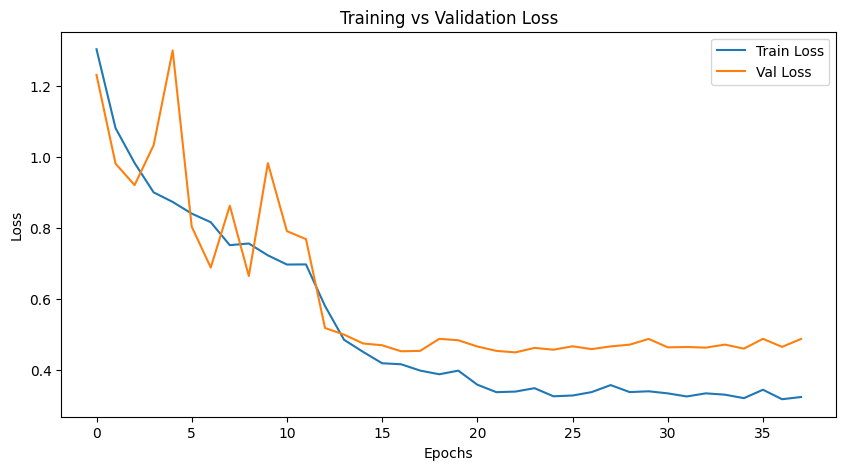

In [91]:
# Plotting the loss curves
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()